In [11]:
import pandas as pd

In [12]:
df = pd.read_csv('merged_dataset.csv')

In [13]:
df.isna().sum()

pcap_file              0
timestamp              0
packet_length          0
src_mac          4648559
dst_mac          4648559
eth_type         4648559
src_ip              6491
dst_ip              6491
ip_version          6491
ttl                 6491
ip_length           6491
tos                 6491
id                  6491
flags_ip            6491
fragment            6491
protocol            6491
src_port         3253539
dst_port         3253539
seq              3253539
ack              3253539
window           3253539
syn                    0
ack_flag               0
fin                    0
rst                    0
psh                    0
urg                    0
udp_length       2900257
icmp_type        4325823
icmp_code        4325823
payload_size           0
Attack Type            0
dtype: int64

#### Structural (Expected) Missing Values

- These occur because the packet protocol does not contain that field.

Ex:

1. TCP packets → udp_length is empty.
2. UDP packets → seq, ack, window are empty.
3. ICMP packets → src_port, dst_port are empty.
4. ARP packets → IP fields are empty.

These should not be considered missing data.

In [14]:
# TCP packets with missing ports
tcp_missing = df[(df["protocol"] == 6) &
                 (df["src_port"].isna() | df["dst_port"].isna())]

print("TCP packets missing ports:", len(tcp_missing))

# UDP packets missing UDP length
udp_missing = df[(df["protocol"] == 17) &
                 (df["udp_length"].isna())]

print("UDP packets missing udp_length:", len(udp_missing))

# ICMP packets missing type/code
icmp_missing = df[(df["protocol"] == 1) &
                  (df["icmp_type"].isna() | df["icmp_code"].isna())]

print("ICMP packets missing fields:", len(icmp_missing))

TCP packets missing ports: 0
UDP packets missing udp_length: 0
ICMP packets missing fields: 0


In [15]:

# 1. DROP UNUSED L2 / META COLUMNS

df = df.drop(columns=["pcap_file", "timestamp"])

df = df.drop(columns=["src_mac", "dst_mac", "eth_type"])

In [16]:

# 2. DROP NON-IP ROWS (STRUCTURAL IP MISSING)
ip_cols = [
    "src_ip", "dst_ip", "ip_version", "ttl",
    "ip_length", "tos", "id",
    "flags_ip", "fragment", "protocol"
]

df = df.dropna(subset=ip_cols)

In [17]:

# 3. HANDLE STRUCTURAL TRANSPORT-LAYER MISSING VALUES

df["src_port"] = df["src_port"].fillna(-1)
df["dst_port"] = df["dst_port"].fillna(-1)

df["seq"] = df["seq"].fillna(-1)
df["ack"] = df["ack"].fillna(-1)
df["window"] = df["window"].fillna(-1)

df["udp_length"] = df["udp_length"].fillna(-1)

df["icmp_type"] = df["icmp_type"].fillna(-1)
df["icmp_code"] = df["icmp_code"].fillna(-1)

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 4642068 entries, 0 to 4648558
Data columns (total 27 columns):
 #   Column         Dtype  
---  ------         -----  
 0   packet_length  int64  
 1   src_ip         str    
 2   dst_ip         str    
 3   ip_version     float64
 4   ttl            float64
 5   ip_length      float64
 6   tos            float64
 7   id             float64
 8   flags_ip       float64
 9   fragment       float64
 10  protocol       float64
 11  src_port       float64
 12  dst_port       float64
 13  seq            float64
 14  ack            float64
 15  window         float64
 16  syn            int64  
 17  ack_flag       int64  
 18  fin            int64  
 19  rst            int64  
 20  psh            int64  
 21  urg            int64  
 22  udp_length     float64
 23  icmp_type      float64
 24  icmp_code      float64
 25  payload_size   int64  
 26  Attack Type    str    
dtypes: float64(16), int64(8), str(3)
memory usage: 991.7 MB


#### Fill structural missing values

Instead of deleting columns or rows, replace them with a sentinel value.

In [19]:
numeric_cols = [
    "src_port",
    "dst_port",
    "seq",
    "ack",
    "window",
    "udp_length",
    "icmp_type",
    "icmp_code"
]

df[numeric_cols] = df[numeric_cols].fillna(-1)

#### Add protocol information

In [21]:
df["is_tcp"] = (df["protocol"] == 6).astype(int)
df["is_udp"] = (df["protocol"] == 17).astype(int)
df["is_icmp"] = (df["protocol"] == 1).astype(int)

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 4642068 entries, 0 to 4648558
Data columns (total 30 columns):
 #   Column         Dtype  
---  ------         -----  
 0   packet_length  int64  
 1   src_ip         str    
 2   dst_ip         str    
 3   ip_version     float64
 4   ttl            float64
 5   ip_length      float64
 6   tos            float64
 7   id             float64
 8   flags_ip       float64
 9   fragment       float64
 10  protocol       float64
 11  src_port       float64
 12  dst_port       float64
 13  seq            float64
 14  ack            float64
 15  window         float64
 16  syn            int64  
 17  ack_flag       int64  
 18  fin            int64  
 19  rst            int64  
 20  psh            int64  
 21  urg            int64  
 22  udp_length     float64
 23  icmp_type      float64
 24  icmp_code      float64
 25  payload_size   int64  
 26  Attack Type    str    
 27  is_tcp         int64  
 28  is_udp         int64  
 29  is_icmp        int64  
dtypes:

In [23]:
df.isna().sum()

packet_length    0
src_ip           0
dst_ip           0
ip_version       0
ttl              0
ip_length        0
tos              0
id               0
flags_ip         0
fragment         0
protocol         0
src_port         0
dst_port         0
seq              0
ack              0
window           0
syn              0
ack_flag         0
fin              0
rst              0
psh              0
urg              0
udp_length       0
icmp_type        0
icmp_code        0
payload_size     0
Attack Type      0
is_tcp           0
is_udp           0
is_icmp          0
dtype: int64

In [25]:
df['Attack Type'].value_counts()

Attack Type
DDoS          3310161
Bruteforce     783806
DOS            408101
Benign         140000
Name: count, dtype: int64

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 4642068 entries, 0 to 4648558
Data columns (total 30 columns):
 #   Column         Dtype  
---  ------         -----  
 0   packet_length  int64  
 1   src_ip         str    
 2   dst_ip         str    
 3   ip_version     float64
 4   ttl            float64
 5   ip_length      float64
 6   tos            float64
 7   id             float64
 8   flags_ip       float64
 9   fragment       float64
 10  protocol       float64
 11  src_port       float64
 12  dst_port       float64
 13  seq            float64
 14  ack            float64
 15  window         float64
 16  syn            int64  
 17  ack_flag       int64  
 18  fin            int64  
 19  rst            int64  
 20  psh            int64  
 21  urg            int64  
 22  udp_length     float64
 23  icmp_type      float64
 24  icmp_code      float64
 25  payload_size   int64  
 26  Attack Type    str    
 27  is_tcp         int64  
 28  is_udp         int64  
 29  is_icmp        int64  
dtypes:

In [28]:
from sklearn.preprocessing import LabelEncoder

src_encoder = LabelEncoder()
dst_encoder = LabelEncoder()

df["src_ip"] = src_encoder.fit_transform(df["src_ip"])
df["dst_ip"] = dst_encoder.fit_transform(df["dst_ip"])

import joblib
import os
os.makedirs("saved", exist_ok=True)
joblib.dump(src_encoder, "saved/src_encoder.pkl")
joblib.dump(dst_encoder, "saved/dst_encoder.pkl")


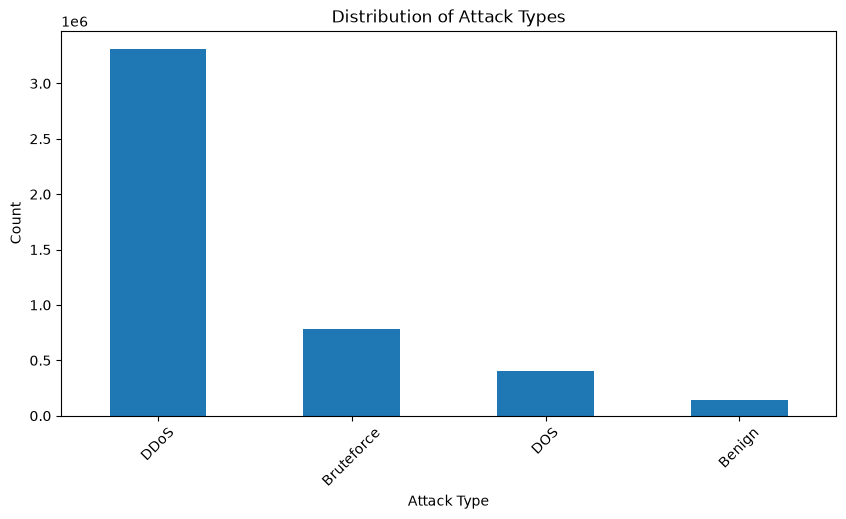

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DISTRIBUTION OF ATTACK TYPES
plt.figure(figsize=(10,5))
df["Attack Type"].value_counts().plot(kind="bar")
plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Mean feature values per attack type:

             packet_length     src_ip     dst_ip  ip_version        ttl  \
Attack Type                                                               
Benign          491.749550  69.692693  70.067236         4.0  64.796336   
Bruteforce     1004.122312  68.597458  72.868762         4.0  64.147553   
DDoS            695.623125  79.879735  74.951840         4.0  70.750649   
DOS             533.135780  76.082416  81.865335         4.0  82.668067   

              ip_length       tos            id  flags_ip  fragment  ...  \
Attack Type                                                          ...   
Benign       475.749550  6.076386  15407.398557  1.887457       0.0  ...   
Bruteforce   988.122312  0.447197  30339.600919  1.176513       0.0  ...   
DDoS         679.620934  2.684840  26448.962307  1.994309       0.0  ...   
DOS          517.135780  4.637700  22582.356610  1.979446       0.0  ...   

                  rst       psh  urg  udp_length  icmp

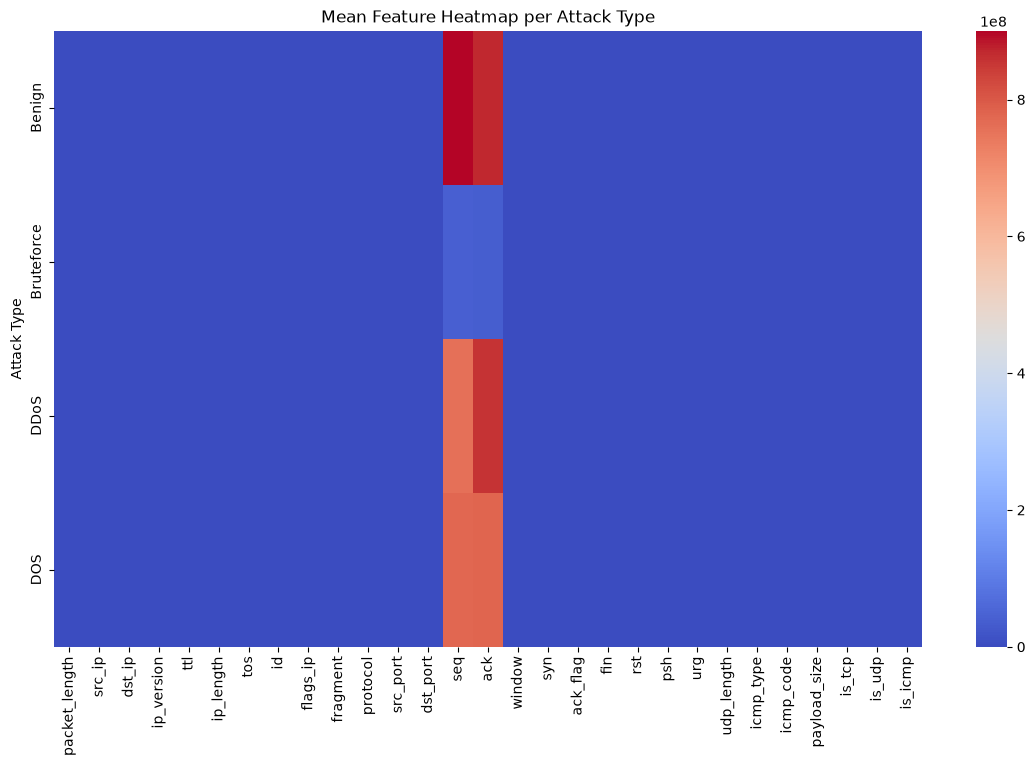

In [30]:

# 2. MEAN COMPARISON (NUMERIC FEATURES)
attack_means = df.groupby("Attack Type").mean(numeric_only=True)

print("Mean feature values per attack type:\n")
print(attack_means)

plt.figure(figsize=(14,8))
sns.heatmap(attack_means, cmap="coolwarm")
plt.title("Mean Feature Heatmap per Attack Type")
plt.show()

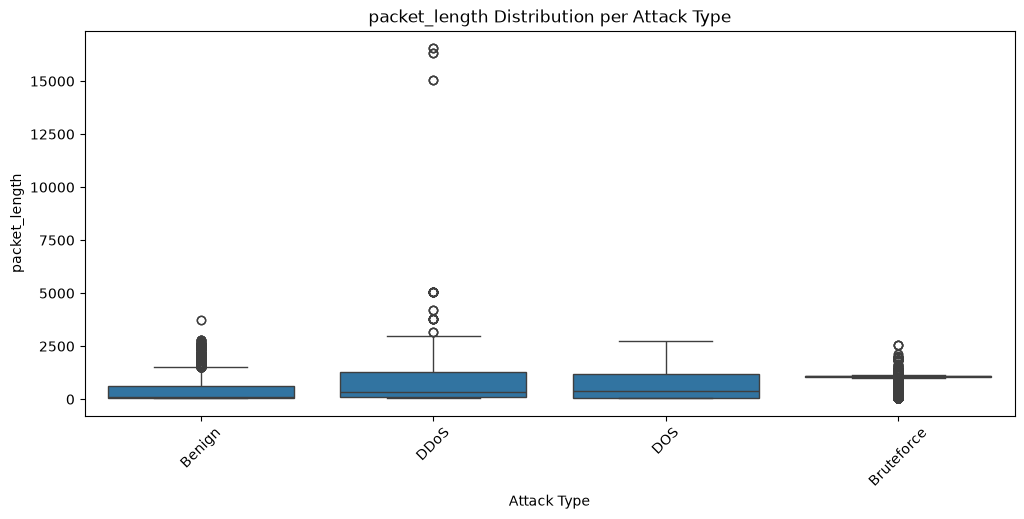

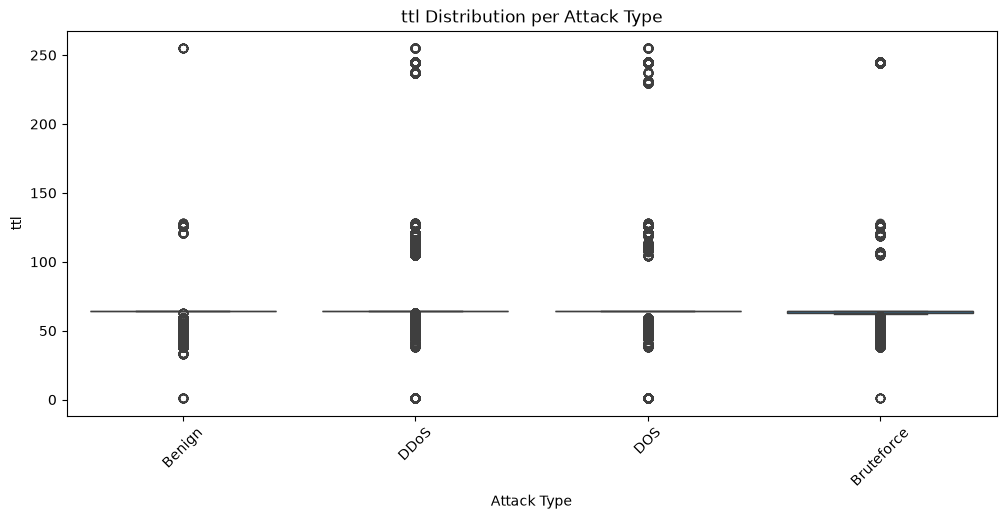

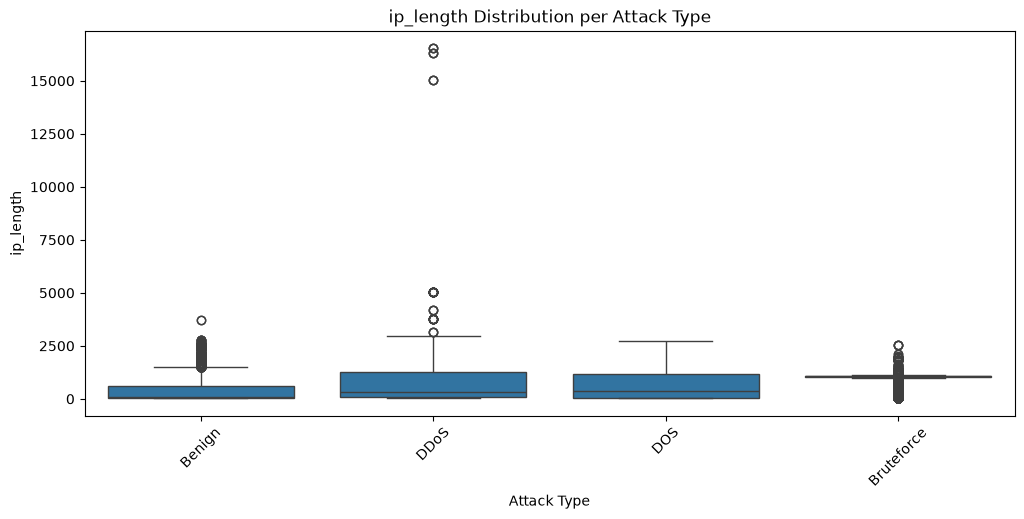

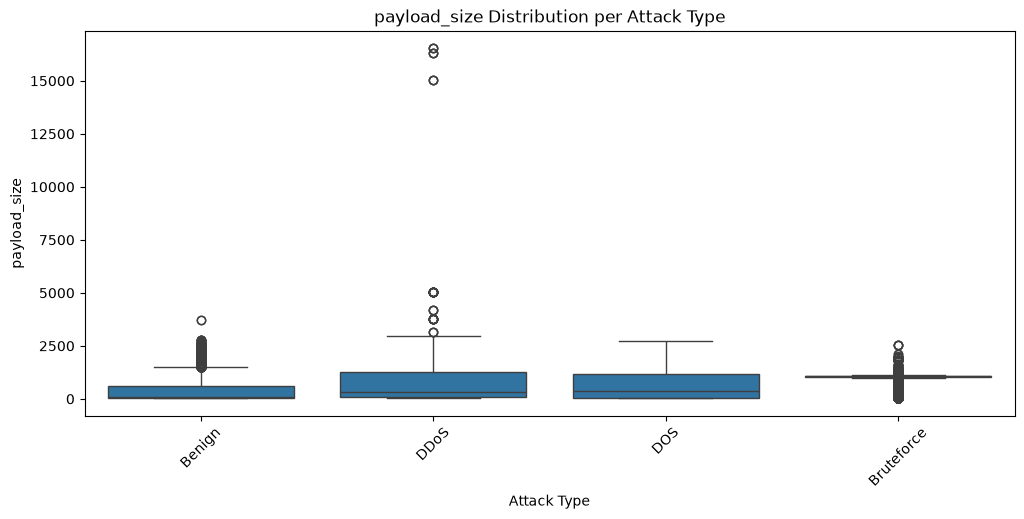

In [31]:

# 3. BOX PLOTS (KEY FEATURES)
key_features = [
    "packet_length",
    "ttl",
    "ip_length",
    "payload_size"
]

for feature in key_features:
    plt.figure(figsize=(12,5))
    sns.boxplot(x="Attack Type", y=feature, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{feature} Distribution per Attack Type")
    plt.show()

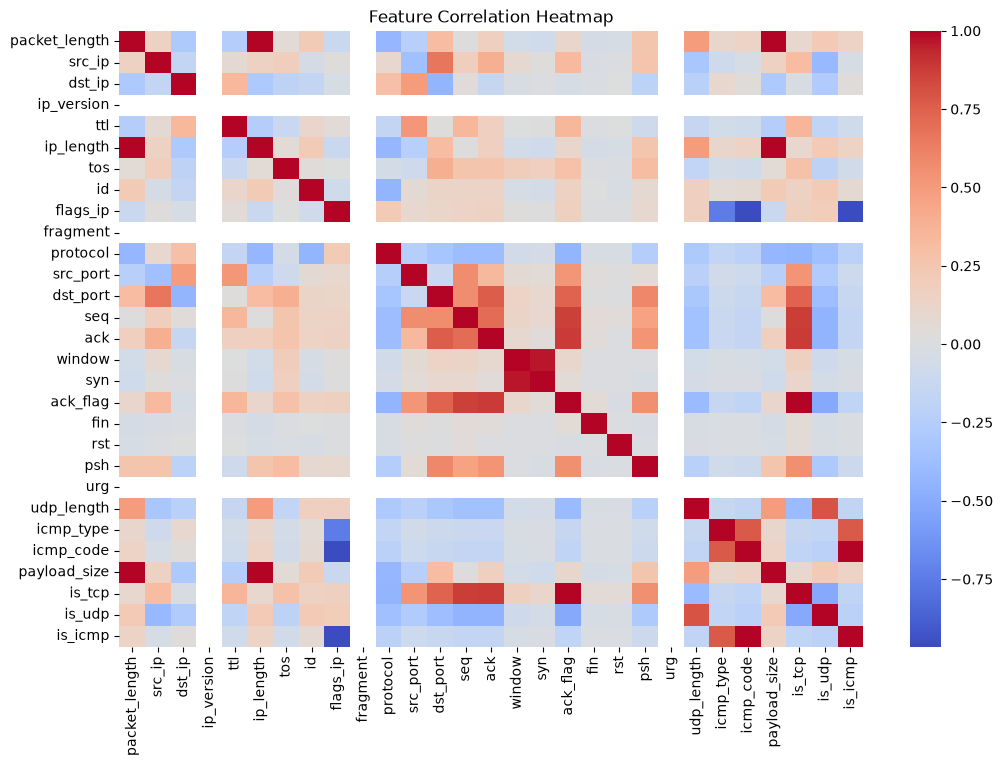

In [32]:

# 4. HEATMAP (CORRELATION INSIGHT)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

<Figure size 1000x500 with 0 Axes>

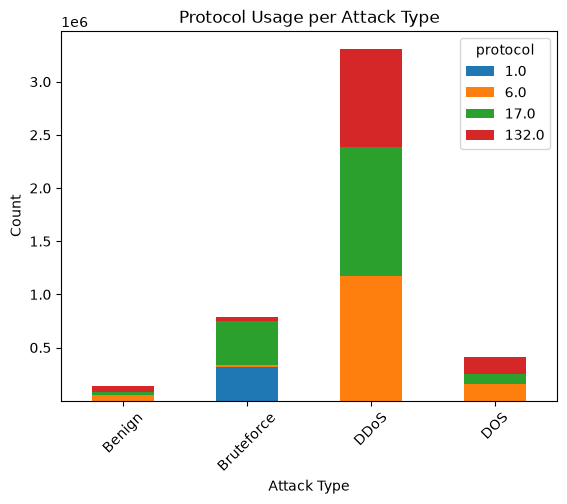

In [33]:
# 5. PROTOCOL USAGE PER ATTACK TYPE
plt.figure(figsize=(10,5))
pd.crosstab(df["Attack Type"], df["protocol"]).plot(kind="bar", stacked=True)
plt.title("Protocol Usage per Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


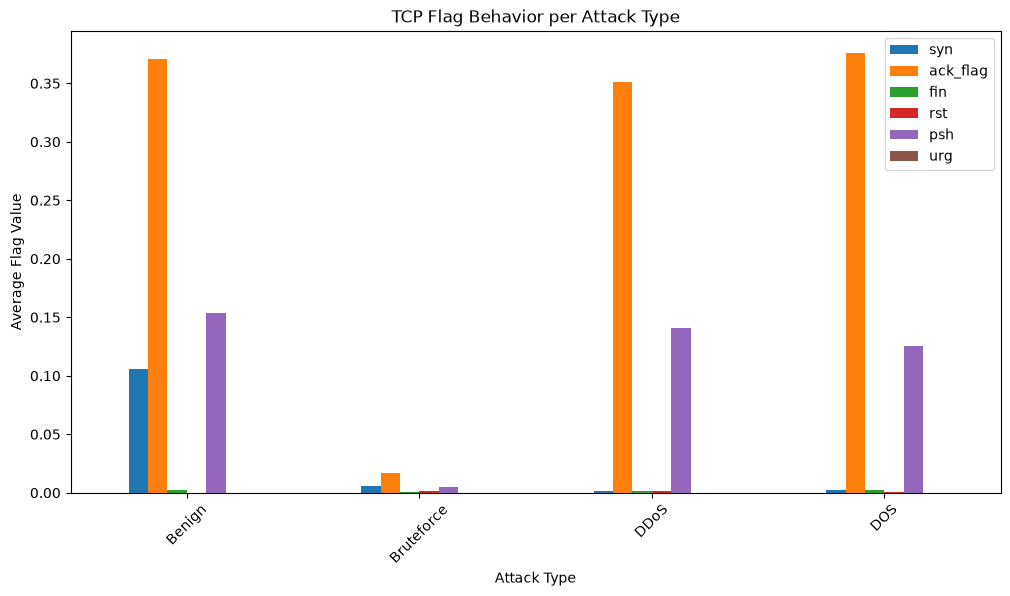

In [34]:
# 6. FLAG BEHAVIOR (IMPORTANT FOR IDS)
flag_cols = ["syn", "ack_flag", "fin", "rst", "psh", "urg"]

df.groupby("Attack Type")[flag_cols].mean().plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("TCP Flag Behavior per Attack Type")
plt.ylabel("Average Flag Value")
plt.xticks(rotation=45)
plt.show()

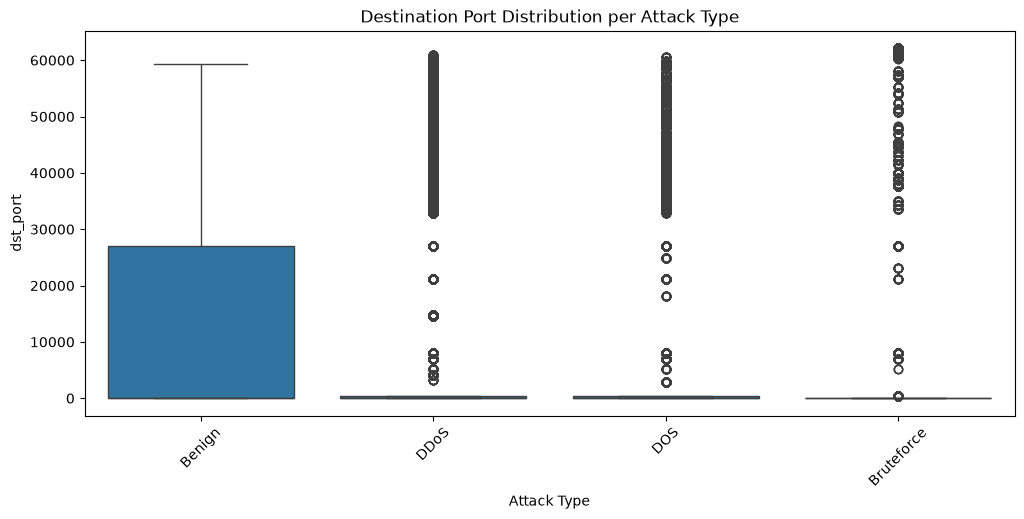

In [35]:
# 7. PORT BEHAVIOR ANALYSIS
# Destination port distribution
plt.figure(figsize=(12,5))
sns.boxplot(x="Attack Type", y="dst_port", data=df)
plt.xticks(rotation=45)
plt.title("Destination Port Distribution per Attack Type")
plt.show()

In [36]:
# Average port usage per attack
print("\nAverage destination port per attack type:\n")
print(df.groupby("Attack Type")["dst_port"].mean())


Average destination port per attack type:

Attack Type
Benign        12698.212471
Bruteforce      550.376245
DDoS          11773.291718
DOS            8771.992904
Name: dst_port, dtype: float64


In [37]:
# 8. HANDLE OUTLIERS BEFORE MODELING
# Clip extreme values using robust percentile-based bounds.
# This is a common choice for network data because real attack traffic can contain very large values.

numeric_cols = [
    col for col in df.select_dtypes(include=['number']).columns
    if col not in ['Attack Type', 'label']
]

print('Checking numeric columns for outliers...')

for col in numeric_cols:
    q1 = df[col].quantile(0.01)
    q3 = df[col].quantile(0.99)
    lower = q1
    upper = q3

    clipped_count = ((df[col] < lower) | (df[col] > upper)).sum()
    if clipped_count > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'{col}: clipped {clipped_count} values to [{lower:.4f}, {upper:.4f}]')
    else:
        print(f'{col}: no extreme values detected')

print('\nOutlier handling complete.')
print(df[numeric_cols].describe().T[['min','max','mean','std']])


Checking numeric columns for outliers...
packet_length: clipped 9711 values to [56.0000, 2544.0000]
src_ip: clipped 69699 values to [42.0000, 160.0000]
dst_ip: clipped 63820 values to [43.0000, 158.0000]
ip_version: no extreme values detected
ttl: clipped 61603 values to [51.0000, 244.0000]
ip_length: clipped 9711 values to [40.0000, 2528.0000]
tos: clipped 7508 values to [0.0000, 72.0000]
id: clipped 46385 values to [0.0000, 64685.0000]
flags_ip: no extreme values detected
fragment: no extreme values detected
protocol: no extreme values detected
src_port: clipped 41968 values to [-1.0000, 52182.0000]
dst_port: clipped 40732 values to [-1.0000, 52182.0000]
seq: clipped 46419 values to [-1.0000, 3990664434.0000]
ack: clipped 46191 values to [-1.0000, 3853496066.0000]
window: clipped 40685 values to [-1.0000, 5209.0000]
syn: clipped 26687 values to [0.0000, 0.0000]
ack_flag: no extreme values detected
fin: clipped 7498 values to [0.0000, 0.0000]
rst: clipped 5061 values to [0.0000, 0.000

In [38]:
# Save the cleaned dataset for modeling
df.to_csv('cleaned_dataset.csv', index=False)